In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os
import random
import time

In [2]:
import torch
import torch.nn as nn
from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader
from torch.utils.data import SubsetRandomSampler
from torch.utils.data import sampler
import torch.nn.functional as F

In [3]:
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'  # or ':16:8'

In [4]:
cuda_device_num = 0
cuda_device = torch.device(f'cuda:{cuda_device_num}' if torch.cuda.is_available() else 'cpu')
print('Device:', cuda_device)

Device: cuda:0


In [5]:
if torch.cuda.is_available():
  # Useful for reproducibility as it ensures that the same algorithms are used across runs.
  torch.backends.cudnn.benchmark = False
  # Ensures that the cuDNN operations are deterministic and, therefore, the same input will produce the same output every time
  torch.backends.cudnn.deterministic = True
# Ensures that operations in PyTorch will behave deterministically
torch.use_deterministic_algorithms(True)

In [6]:
my_seed = 101
os.environ["PL_GLOBAL_SEED"] = str(my_seed)
random.seed(my_seed)
np.random.seed(my_seed)
torch.manual_seed(my_seed)
torch.cuda.manual_seed_all(my_seed)

In [7]:
lr_rate = 0.0005
batch_size = 32
num_epochs = 20

In [8]:
def get_dataloaders_celeba(batch_size, num_workers=0,
                           validation_fraction=None,
                           train_transforms=None, test_transforms=None):

    if train_transforms is None:
        train_transforms = transforms.Compose([
            transforms.Resize((64, 64)),  # Resize to a common size
            transforms.ToTensor(),
        ])

    if test_transforms is None:
        test_transforms = transforms.Compose([
            transforms.Resize((64, 64)),
            transforms.ToTensor(),
        ])

    # Load the CelebA dataset
    train_dataset = datasets.CelebA(root='data',
                                     split='train',
                                     transform=train_transforms,
                                     download=True)

    valid_dataset = datasets.CelebA(root='data',
                                     split='train',
                                     transform=test_transforms)  # Use test transforms for validation

    test_dataset = datasets.CelebA(root='data',
                                    split='test',
                                    transform=test_transforms)

    # If validation_fraction is specified, create validation split
    if validation_fraction is not None:
        num = int(validation_fraction * len(train_dataset))
        train_indices = torch.arange(0, len(train_dataset) - num)
        valid_indices = torch.arange(len(train_dataset) - num, len(train_dataset))

        train_sampler = SubsetRandomSampler(train_indices)
        valid_sampler = SubsetRandomSampler(valid_indices)

        valid_loader = DataLoader(dataset=valid_dataset,
                                  batch_size=batch_size,
                                  num_workers=num_workers,
                                  sampler=valid_sampler)

        train_loader = DataLoader(dataset=train_dataset,
                                  batch_size=batch_size,
                                  num_workers=num_workers,
                                  drop_last=True,
                                  sampler=train_sampler)
    else:
        train_loader = DataLoader(dataset=train_dataset,
                                  batch_size=batch_size,
                                  num_workers=num_workers,
                                  shuffle=True)

    test_loader = DataLoader(dataset=test_dataset,
                             batch_size=batch_size,
                             num_workers=num_workers,
                             shuffle=False)

    if validation_fraction is None:
        return train_loader, test_loader
    else:
        return train_loader, valid_loader, test_loader

In [9]:
train_loader, valid_loader, test_loader = get_dataloaders_celeba(
    batch_size = batch_size,
    num_workers = 2,
    validation_fraction = 0.)

Downloading...
From (original): https://drive.google.com/uc?id=0B7EVK8r0v71pZjFTYXZWM3FlRnM
From (redirected): https://drive.usercontent.google.com/download?id=0B7EVK8r0v71pZjFTYXZWM3FlRnM&confirm=t&uuid=87b10c8c-a4cb-4c7b-8d41-54b8b8f5e6be
To: /content/data/celeba/img_align_celeba.zip
100%|██████████| 1.44G/1.44G [00:28<00:00, 50.5MB/s]
Downloading...
From: https://drive.google.com/uc?id=0B7EVK8r0v71pblRyaVFSWGxPY0U
To: /content/data/celeba/list_attr_celeba.txt
100%|██████████| 26.7M/26.7M [00:00<00:00, 132MB/s] 
Downloading...
From: https://drive.google.com/uc?id=1_ee_0u7vcNLOfNLegJRHmolfH5ICW-XS
To: /content/data/celeba/identity_CelebA.txt
100%|██████████| 3.42M/3.42M [00:00<00:00, 253MB/s]
Downloading...
From: https://drive.google.com/uc?id=0B7EVK8r0v71pbThiMVRxWXZ4dU0
To: /content/data/celeba/list_bbox_celeba.txt
100%|██████████| 6.08M/6.08M [00:00<00:00, 22.5MB/s]
Downloading...
From: https://drive.google.com/uc?id=0B7EVK8r0v71pd0FJY3Blby1HUTQ
To: /content/data/celeba/list_landma

In [10]:
# Dataset Sanity check 1:
print('Training Set:\n')
for images, labels in train_loader:
    print('Image batch dimensions:', images.size())
    print('Image label dimensions:', labels.size())
    print(labels[:10])
    break

# Dataset Sanity check 2:
print('\nValidation Set:')
for images, labels in valid_loader:
    print('Image batch dimensions:', images.size())
    print('Image label dimensions:', labels.size())
    print(labels[:10])
    break

# Dataset Sanity check 3:
print('\nTesting Set:')
for images, labels in test_loader:
    print('Image batch dimensions:', images.size())
    print('Image label dimensions:', labels.size())
    print(labels[:10])
    break

Training Set:

Image batch dimensions: torch.Size([32, 3, 64, 64])
Image label dimensions: torch.Size([32, 40])
tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
         1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1],
        [0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
         1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1],
        [0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1],
        [0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1,
         1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1],
        [1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0,
         0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1],
        [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
         1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1],
        [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [11]:
# Helper Class 1: Reshape is used to reshape the embeddings to the correct image size
class Reshape(nn.Module):
    def __init__(self, *args):
        super().__init__()
        self.shape = args

    def forward(self, x):
        return x.view(self.shape)

In [12]:
# Helper Class 2: Trim is used to remove the excess pixels at the output of the decoder block (28x28 as MNIST size)
class Trim(nn.Module):
    def __init__(self, *args):
        super().__init__()

    def forward(self, x):
        return x[:, :, :28, :28]

In [74]:
class Conv_AutoEncoder(nn.Module):
    def __init__(self, embedding_size=64):
        super().__init__()
        self.embedding_size = embedding_size

        # Encoder for CelebA (3 channels, 64x64 images)
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, stride=(1, 1), kernel_size=(3, 3), padding=1),
            nn.LeakyReLU(0.01),
            nn.Conv2d(32, 64, stride=(2, 2), kernel_size=(3, 3), padding=1),  # 32x32
            nn.LeakyReLU(0.01),
            nn.Conv2d(64, 128, stride=(2, 2), kernel_size=(3, 3), padding=1),  # 16x16
            nn.LeakyReLU(0.01),
            nn.Conv2d(128, 256, stride=(2, 2), kernel_size=(3, 3), padding=1),  # 8x8
            nn.LeakyReLU(0.01),
            nn.Conv2d(256, 512, stride=(2, 2), kernel_size=(3, 3), padding=1),  # 4x4
            nn.LeakyReLU(0.01),
            nn.Flatten(),
            nn.Linear(512 * 4 * 4, embedding_size)
        )

        # Decoder for CelebA
        self.decoder = nn.Sequential(
            nn.Linear(embedding_size, 512 * 4 * 4),
            Reshape(-1, 512, 4, 4),
            nn.ConvTranspose2d(512, 256, stride=(2, 2), kernel_size=(3, 3), padding=1, output_padding=1),  # 8x8
            nn.LeakyReLU(0.01),
            nn.ConvTranspose2d(256, 128, stride=(2, 2), kernel_size=(3, 3), padding=1, output_padding=1),  # 16x16
            nn.LeakyReLU(0.01),
            nn.ConvTranspose2d(128, 64, stride=(2, 2), kernel_size=(3, 3), padding=1, output_padding=1),  # 32x32
            nn.LeakyReLU(0.01),
            nn.ConvTranspose2d(64, 32, stride=(2, 2), kernel_size=(3, 3), padding=1, output_padding=1),  # 64x64
            nn.LeakyReLU(0.01),
            nn.ConvTranspose2d(32, 3, stride=(1, 1), kernel_size=(3, 3), padding=1),  # 64x64
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [75]:
model = Conv_AutoEncoder()
model.to(cuda_device)

optimizer = torch.optim.Adam(model.parameters(), lr = lr_rate)

In [76]:
def compute_epoch_loss_autoencoder(model, data_loader, loss_fn, device):
    model.eval()
    curr_loss, num_examples = 0., 0
    with torch.no_grad():
        for features, _ in data_loader:
            features = features.to(device)
            logits = model(features)
            loss = loss_fn(logits, features, reduction = 'sum')
            num_examples += features.size(0)
            curr_loss += loss

        curr_loss = curr_loss / num_examples
        return curr_loss

In [80]:
def train_autoencoder_v1(num_epochs, model, optimizer, device,
                         train_loader, loss_fn = None,
                         logging_interval = 100,
                         skip_epoch_stats = False,
                         save_model = None):

    log_dict = {'train_loss_per_batch': [],
                'train_loss_per_epoch': []}

    if loss_fn is None:
        loss_fn = F.mse_loss

    start_time = time.time()
    for epoch in range(num_epochs):

        model.train()
        for batch_idx, (features, _) in enumerate(train_loader):

            features = features.to(device)

            # Forward and backpropagation ste[s]
            logits = model(features)
            loss = loss_fn(logits, features)
            optimizer.zero_grad()

            loss.backward()

            # Model weights' update
            optimizer.step()

            # Performance logging
            log_dict['train_loss_per_batch'].append(loss.item())

            if not batch_idx % logging_interval:
                print('Epoch: %03d/%03d | Batch %04d/%04d | Loss: %.4f'
                      % (epoch+1, num_epochs, batch_idx,
                          len(train_loader), loss))

        if not skip_epoch_stats:
            model.eval()

            with torch.set_grad_enabled(False):  # Will help save memory during inference

                train_loss = compute_epoch_loss_autoencoder(
                    model, train_loader, loss_fn, device)
                print('***Epoch: %03d/%03d | Loss: %.3f' % (
                      epoch+1, num_epochs, train_loss))
                log_dict['train_loss_per_epoch'].append(train_loss.item())

        print('Time elapsed: %.2f min' % ((time.time() - start_time)/60))

    print('Total Training Time: %.2f min' % ((time.time() - start_time)/60))
    if save_model is not None:
        torch.save(model.state_dict(), save_model)

    return log_dict

In [81]:
log_dict = train_autoencoder_v1(num_epochs = num_epochs, model = model,
                                optimizer = optimizer, device = cuda_device,
                                train_loader = train_loader,
                                skip_epoch_stats = True,
                                logging_interval = 250)

Epoch: 001/020 | Batch 0000/5086 | Loss: 0.0079
Epoch: 001/020 | Batch 0250/5086 | Loss: 0.0076
Epoch: 001/020 | Batch 0500/5086 | Loss: 0.0090
Epoch: 001/020 | Batch 0750/5086 | Loss: 0.0077
Epoch: 001/020 | Batch 1000/5086 | Loss: 0.0078
Epoch: 001/020 | Batch 1250/5086 | Loss: 0.0068
Epoch: 001/020 | Batch 1500/5086 | Loss: 0.0073
Epoch: 001/020 | Batch 1750/5086 | Loss: 0.0091
Epoch: 001/020 | Batch 2000/5086 | Loss: 0.0065
Epoch: 001/020 | Batch 2250/5086 | Loss: 0.0083
Epoch: 001/020 | Batch 2500/5086 | Loss: 0.0066
Epoch: 001/020 | Batch 2750/5086 | Loss: 0.0069
Epoch: 001/020 | Batch 3000/5086 | Loss: 0.0076
Epoch: 001/020 | Batch 3250/5086 | Loss: 0.0077
Epoch: 001/020 | Batch 3500/5086 | Loss: 0.0076
Epoch: 001/020 | Batch 3750/5086 | Loss: 0.0062
Epoch: 001/020 | Batch 4000/5086 | Loss: 0.0079
Epoch: 001/020 | Batch 4250/5086 | Loss: 0.0065
Epoch: 001/020 | Batch 4500/5086 | Loss: 0.0077
Epoch: 001/020 | Batch 4750/5086 | Loss: 0.0072
Epoch: 001/020 | Batch 5000/5086 | Loss:

In [82]:
torch.save(model.state_dict(), '/content/conv_ae_model.pth')

In [83]:
torch.save(model, '/content/conv_ae_model_complete.pth')

In [84]:
def plot_training_loss(minibatch_losses, num_epochs, averaging_iterations = 100, custom_label = ''):

    iter_per_epoch = len(minibatch_losses) // num_epochs

    plt.figure()
    ax1 = plt.subplot(1, 1, 1)
    ax1.plot(range(len(minibatch_losses)),
             (minibatch_losses), label = f'Minibatch Loss{custom_label}')
    ax1.set_xlabel('Iterations')
    ax1.set_ylabel('Loss')

    if len(minibatch_losses) < 1000:
        num_losses = len(minibatch_losses) // 2
    else:
        num_losses = 1000

    ax1.set_ylim([
        0, np.max(minibatch_losses[num_losses:])*1.5
        ])

    ax1.plot(np.convolve(minibatch_losses,
                         np.ones(averaging_iterations,)/averaging_iterations,
                         mode = 'valid'),
             label = f'Running Average{custom_label}')
    ax1.legend()

    ###################
    # Set scond x-axis
    ax2 = ax1.twiny()
    newlabel = list(range(num_epochs+1))

    newpos = [e*iter_per_epoch for e in newlabel]

    ax2.set_xticks(newpos[::10])
    ax2.set_xticklabels(newlabel[::10])

    ax2.xaxis.set_ticks_position('bottom')
    ax2.xaxis.set_label_position('bottom')
    ax2.spines['bottom'].set_position(('outward', 45))
    ax2.set_xlabel('Epochs')
    ax2.set_xlim(ax1.get_xlim())
    ###################

    plt.tight_layout()

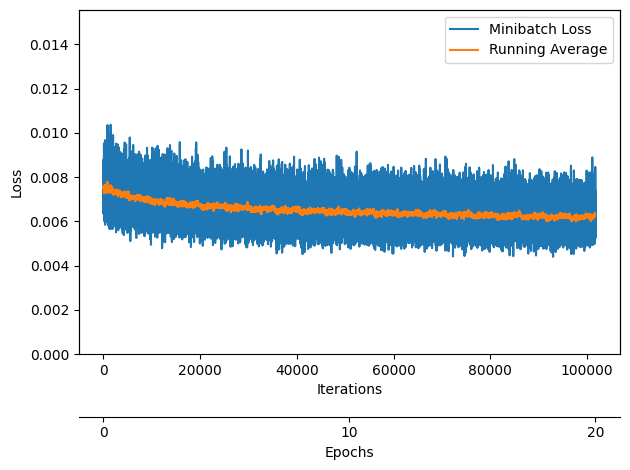

In [85]:
plot_training_loss(log_dict['train_loss_per_batch'], num_epochs)
plt.show()

In [86]:
def plot_generated_images(data_loader, model, device,
                          unnormalizer = None,
                          figsize = (20, 2.5), n_images = 15, modeltype = 'autoencoder'):

    fig, axes = plt.subplots(nrows = 2, ncols = n_images,
                             sharex = True, sharey = True, figsize = figsize)

    for batch_idx, (features, _) in enumerate(data_loader):

        features = features.to(device)

        color_channels = features.shape[1]
        image_height = features.shape[2]
        image_width = features.shape[3]

        with torch.no_grad():
            if modeltype == 'autoencoder':
                decoded_images = model(features)[:n_images]
            elif modeltype == 'VAE':
                encoded, z_mean, z_log_var, decoded_images = model(features)[:n_images]
            else:
                raise ValueError('`modeltype` not supported')

        orig_images = features[:n_images]
        break

    for i in range(n_images):
        for ax, img in zip(axes, [orig_images, decoded_images]):
            curr_img = img[i].detach().to(torch.device('cpu'))
            if unnormalizer is not None:
                curr_img = unnormalizer(curr_img)

            if color_channels > 1:
                curr_img = np.transpose(curr_img, (1, 2, 0))
                ax[i].imshow(curr_img)
            else:
                ax[i].imshow(curr_img.view((image_height, image_width)), cmap = 'binary')

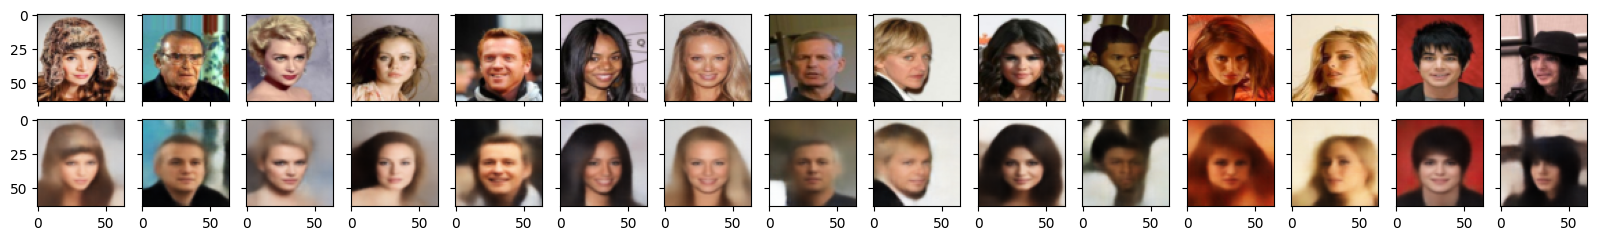

In [87]:
plot_generated_images(data_loader = train_loader, model = model, device = cuda_device)

In [88]:
def plot_latent_space_with_labels(num_classes, data_loader, model, device):
    d = {i:[] for i in range(num_classes)}

    model.eval()
    with torch.no_grad():
        for i, (features, targets) in enumerate(data_loader):

            features = features.to(device)
            targets = targets.to(device)

            embedding = model.encoder(features)
            # CelebA has 40 labels, select the first 'num_classes'
            targets = targets[:, :num_classes] # Select the relevant labels

            for i in range(num_classes):
                if i in targets:
                    mask = targets[:, i] == 1 # Check for attribute presence in the relevant column
                    d[i].append(embedding[mask].to('cpu').numpy())

    colors = list(mcolors.TABLEAU_COLORS.items())
    for i in range(num_classes):
        if d[i]: #Check if list is not empty
            d[i] = np.concatenate(d[i])
            plt.scatter(
                d[i][:, 0], d[i][:, 1],
                color = colors[i][1],
                label = f'{i}',
                alpha = 0.5)

    plt.legend()

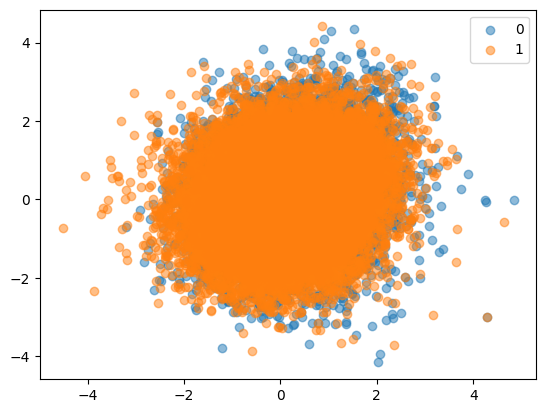

In [89]:
num_classes = 10
plot_latent_space_with_labels(
    num_classes = num_classes,
    data_loader = train_loader,
    model = model,
    device = cuda_device)

plt.legend()
plt.show()

In [108]:
#PCA to display the 2D projection
def plot_latent_space_with_pca(embeddings, labels, num_classes=10, title="PCA Projection"):
    pca = PCA(n_components=2)
    embeddings_2d = pca.fit_transform(embeddings)

    plt.figure(figsize=(10, 8))
    colors = list(mcolors.TABLEAU_COLORS.values())
    # Assuming labels are multi-label, pick the first label as the primary label
    primary_labels = labels[:, 0]  # Use the first column (label) for visualization

    for i in range(num_classes):
        idx = (primary_labels == i)  # Filter based on the primary label
        plt.scatter(
            embeddings_2d[idx, 0],
            embeddings_2d[idx, 1],
            color=colors[i % len(colors)],
            label=f'{i}',
            alpha=0.6
        )

    plt.title(title)
    plt.xlabel(f"PC1 (Explained Var: {pca.explained_variance_ratio_[0]:.2f})")
    plt.ylabel(f"PC2 (Explained Var: {pca.explained_variance_ratio_[1]:.2f})")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [109]:
# t-SNE projection
def plot_latent_space_with_tsne(embeddings, labels, num_classes=10, title="t-SNE Projection"):
    tsne = TSNE(n_components=2, perplexity=30, random_state=my_seed)
    embeddings_2d = tsne.fit_transform(embeddings)

    plt.figure(figsize=(10, 8))
    colors = list(mcolors.TABLEAU_COLORS.values())

    # Assuming labels are multi-label, pick the first label as the primary label
    primary_labels = labels[:, 0]  # Use the first column (label) for visualization

    for i in range(num_classes):
        idx = (primary_labels == i)  # Filter based on the primary label
        plt.scatter(
            embeddings_2d[idx, 0],
            embeddings_2d[idx, 1],
            color=colors[i % len(colors)],
            label=f'{i}',
            alpha=0.6
        )

    plt.title(title)
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.legend()
    plt.tight_layout()
    plt.show()



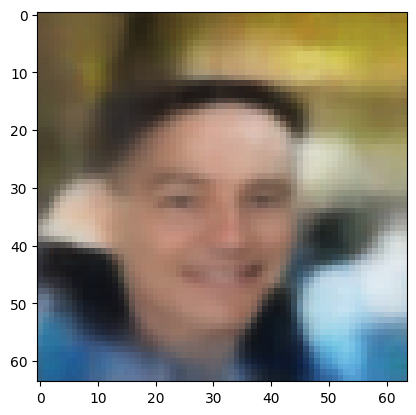

In [110]:
with torch.no_grad():
    # Create a random latent vector of size 64 (embedding_size)
    random_latent_vector = torch.randn(64).to(cuda_device)
    new_image = model.decoder(random_latent_vector)
    new_image.squeeze_(0)

plt.imshow(new_image.to('cpu').numpy().transpose(1, 2, 0), cmap = 'binary')  # Assuming 3 channels in the output
plt.show()

In [111]:
model = Conv_AutoEncoder()  # Initialize the model
# Option 1: Loading model params
model.load_state_dict(torch.load('/content/conv_ae_model.pth'))
model.to(cuda_device) # This line is added to move the model to the GPU
model.eval()  # Set to evaluation mode

# Option 2: Loading full model
# model = torch.load('/content/conv_ae_model_complete.pth')
# model.eval()  # Set to evaluation mode

Conv_AutoEncoder(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.01)
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): LeakyReLU(negative_slope=0.01)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): LeakyReLU(negative_slope=0.01)
    (6): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (7): LeakyReLU(negative_slope=0.01)
    (8): Conv2d(256, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (9): LeakyReLU(negative_slope=0.01)
    (10): Flatten(start_dim=1, end_dim=-1)
    (11): Linear(in_features=8192, out_features=64, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=64, out_features=8192, bias=True)
    (1): Reshape()
    (2): ConvTranspose2d(512, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): LeakyReLU(negative_slope=0.01)
    (4): Conv

In [112]:
all_embeddings = torch.zeros((10_000, model.embedding_size))  # Use embedding size from the model
num_images = 0
for images, labels in train_loader:

    if num_images >= 10_000:
        break

    begin = num_images
    end = begin + images.size(0)
    end = min(end, 10_000)


    images, labels = images.to(cuda_device), labels.to(cuda_device)

    with torch.no_grad():
        embeddings = model.encoder(images).to('cpu')

    # Adjust the slice size to match the available space:
    all_embeddings[begin:end] = embeddings[:end-begin]


    num_images = end

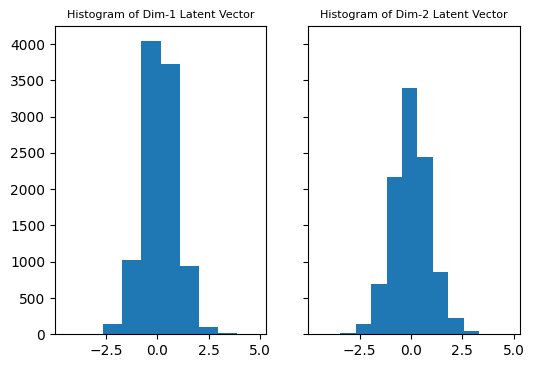

In [113]:
fig, axes = plt.subplots(nrows = 1, ncols = 2,
                         sharex = True, sharey = True,
                         figsize = (6, 4))

axes[0].hist(all_embeddings[:, 0].numpy())
axes[0].set_title('Histogram of Dim-1 Latent Vector', fontsize = 8)
axes[1].hist(all_embeddings[:, 1].numpy())
axes[1].set_title('Histogram of Dim-2 Latent Vector', fontsize = 8)
plt.show()

#PCA & t-SNE visualization



In [114]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

Collected 10000 embeddings with dimension 64
PCA visualization


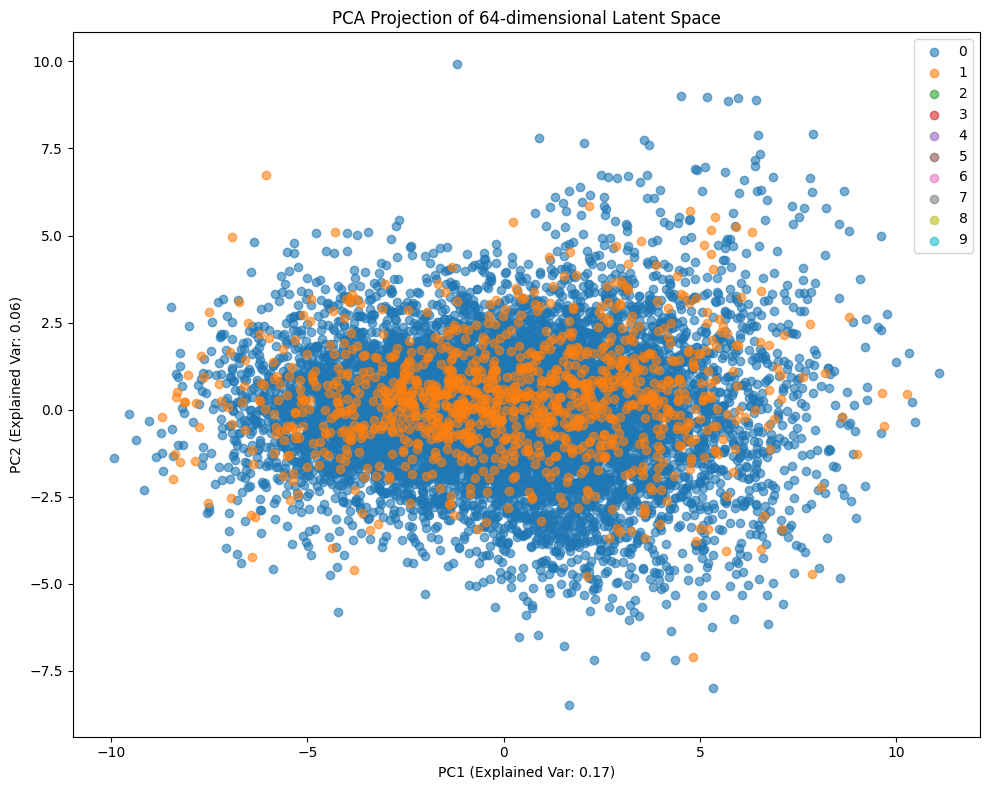

t-SNE visualization


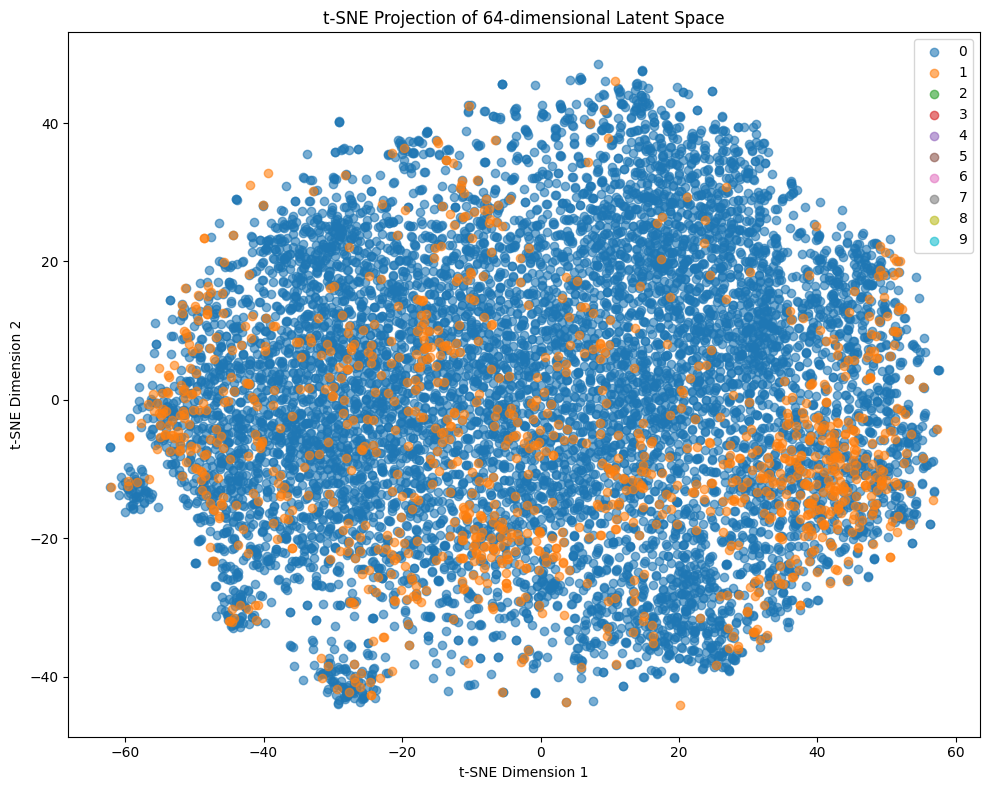

In [115]:
# Collect embeddings for visualization
all_embeddings = []
all_labels = []
num_samples = 0

model.eval()
with torch.no_grad():
    for images, labels in train_loader:
        if num_samples >= 10000:
            break

        images = images.to(cuda_device)
        current_batch_size = min(images.size(0), 10000 - num_samples)

        # Extract embeddings
        embeddings = model.encoder(images[:current_batch_size]).cpu().numpy()
        batch_labels = labels[:current_batch_size].numpy()

        all_embeddings.append(embeddings)
        all_labels.append(batch_labels)

        num_samples += current_batch_size

# Stack all collected embeddings and labels
all_embeddings = np.vstack(all_embeddings)
all_labels = np.concatenate(all_labels)
embedding_size = all_embeddings.shape[1]
print(f"Collected {all_embeddings.shape[0]} embeddings with dimension {embedding_size}")

# Visualize with PCA
print("PCA visualization")
plot_latent_space_with_pca(
    all_embeddings,
    all_labels,
    title=f"PCA Projection of {embedding_size}-dimensional Latent Space"
)

# Visualize with t-SNE
print("t-SNE visualization")
plot_latent_space_with_tsne(
    all_embeddings,
    all_labels,
    title=f"t-SNE Projection of {embedding_size}-dimensional Latent Space"
)

##Modify dimension and generate GIF (Task 6,7)

---



In [116]:
import imageio

# The first dimension of the latent vector
def create_interpolation_gif_dim1(model, image, device=cuda_device, save_path="dimension1.gif"):
    model.eval()
    images = []

    with torch.no_grad():
        image = image.to(device)
        embedding = model.encoder(image.unsqueeze(0)).squeeze(0).cpu().numpy()

        for val in np.arange(-10, 10.1, 0.1):
            modified = embedding.copy()
            modified[0] = val  # Change 1st dimension
            modified_tensor = torch.tensor(modified, dtype=torch.float32).unsqueeze(0).to(device)
            reconstructed = model.decoder(modified_tensor).cpu().squeeze(0).detach().numpy()  # squeeze(0) for removing the batch dimension

            # Ensure the image has the correct shape and data type
            img = np.transpose(reconstructed, (1, 2, 0)) # Transpose to (height, width, channels)
            img = (img * 255).astype(np.uint8)
            images.append(img)

    imageio.mimsave(save_path, images, fps=15)
    print(f"GIF saved to {save_path}")

# Select one image from the test set
test_iter = iter(test_loader)
image, _ = next(test_iter)
image = image[0]

# Generate GIF
create_interpolation_gif_dim1(model, image)

GIF saved to dimension1.gif


In [117]:
def create_interpolation_gif_dim2(model, image, device=cuda_device, save_path="dimension2.gif"):
    model.eval()
    images = []

    with torch.no_grad():
        image = image.to(device)
        embedding = model.encoder(image.unsqueeze(0)).squeeze(0).cpu().numpy()

        for val in np.arange(-10, 10.1, 0.1):
            modified = embedding.copy()
            modified[1] = val  # Change 2nd dimension
            modified_tensor = torch.tensor(modified, dtype=torch.float32).unsqueeze(0).to(device)

            # Corrected line: Keep the necessary dimensions for the image
            reconstructed = model.decoder(modified_tensor).cpu().squeeze(0).detach().numpy()

            # Ensure the image has the correct shape and data type
            img = np.transpose(reconstructed, (1, 2, 0))  # Transpose to (height, width, channels)
            img = (img * 255).astype(np.uint8)
            images.append(img)

    imageio.mimsave(save_path, images, fps=15)
    print(f"GIF saved to {save_path}")

    # Select one image from the test set
test_iter = iter(test_loader)
image, _ = next(test_iter)
image = image[0]

# Generate GIF
create_interpolation_gif_dim2(model, image)

GIF saved to dimension2.gif
